In [ ]:
!pip install torch torchvision gradio transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from transformers import AutoFeatureExtractor, AutoModelForImageClassification
import gradio as gr


Define Dataset Path and Lazy Dataset Class

In [ ]:
# Define dataset path (update this if needed)
dataset_path = '/content/drive/MyDrive/dataset'

# Define custom dataset class for lazy loading
class BloodCancerDataset(Dataset):
    def __init__(self, folder_paths, labels, transform):
        self.folder_paths = folder_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.folder_paths)

    def __getitem__(self, idx):
        img_path = self.folder_paths[idx]
        label = self.labels[idx]

        # Load image lazily and apply transformations
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        return image, label

# Define transforms with resizing to reduce memory usage
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize early to save memory
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize early to save memory
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


Load Dataset Paths and Prepare Data Loaders

In [ ]:
# Load file paths and labels lazily
file_paths = []
labels = []
label_map = {'Benign': 0, 'Malignant early Pre-B': 1, 'Malignant Pre-B': 2, 'Malignant Pro-B': 3}

for folder, label in label_map.items():
    folder_path = os.path.join(dataset_path, folder)
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isdir(img_path):  # Skip directories
            continue
        file_paths.append(img_path)
        labels.append(label)

# Split dataset into training and validation sets (80% train, 20% validation)
train_paths, val_paths, train_labels, val_labels = train_test_split(file_paths, labels, test_size=0.2, random_state=42)

# Create dataset instances for training and validation sets
train_dataset = BloodCancerDataset(train_paths, train_labels, transform_train)
val_dataset = BloodCancerDataset(val_paths, val_labels, transform_val)

# Create data loaders for training and validation sets (optimize batch size for Colab T4 GPU)
batch_size = 16  # Lower batch size to avoid memory overflow on free-tier GPUs
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


Load Pre-trained ConvNeXt Model and Modify Classifier

In [ ]:
# Load pre-trained ConvNeXt model and feature extractor from Hugging Face Transformers library
model_name = "facebook/convnext-tiny-224"
model = AutoModelForImageClassification.from_pretrained(model_name)
feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)

# Modify the classifier layer to match the number of classes (4 classes in this case)
num_classes = len(label_map)  # Number of classes in the dataset (4)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/114M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/convnext/feature_extraction_convnext.py:28: FutureWarning: The class ConvNextFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ConvNextImageProcessor instead.
  warnings.warn(


ConvNextForImageClassification(
  (convnext): ConvNextModel(
    (embeddings): ConvNextEmbeddings(
      (patch_embeddings): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (layernorm): ConvNextLayerNorm()
    )
    (encoder): ConvNextEncoder(
      (stages): ModuleList(
        (0): ConvNextStage(
          (downsampling_layer): Identity()
          (layers): Sequential(
            (0): ConvNextLayer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
              (layernorm): ConvNextLayerNorm()
              (pwconv1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELUActivation()
              (pwconv2): Linear(in_features=384, out_features=96, bias=True)
              (drop_path): Identity()
            )
            (1): ConvNextLayer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
              (layernorm): ConvNextLayerNorm()
              

Train the Model with Mixed Precision

In [ ]:
# Define optimizer and loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

# Mixed precision context manager for training loop
scaler = torch.cuda.amp.GradScaler()

epochs = 25

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        inputs, labels = batch

        # Move data to GPU if available
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward pass with mixed precision enabled
        with torch.cuda.amp.autocast():
            outputs = model(inputs).logits
            loss = criterion(outputs, labels)

        # Backward pass and optimization step with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader)}")

    # Validation accuracy calculation after each epoch
    model.eval()
    correct_predictions = 0

    with torch.no_grad():
        for batch in val_loader:
            inputs, labels = batch

            # Move data to GPU if available
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs).logits
            _, predictions = torch.max(outputs, dim=1)

            correct_predictions += (predictions == labels).sum().item()

    accuracy = correct_predictions / len(val_dataset)
    print(f"Validation Accuracy after Epoch {epoch+1}: {accuracy:.4f}")


<ipython-input-5-ab77b346630b>:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
<ipython-input-5-ab77b346630b>:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/25, Loss: 0.8233349337899611
Validation Accuracy after Epoch 1: 0.9446
Epoch 2/25, Loss: 0.20050434978461704
Validation Accuracy after Epoch 2: 0.9877
Epoch 3/25, Loss: 0.06375468435462998
Validation Accuracy after Epoch 3: 0.9831
Epoch 4/25, Loss: 0.031157205441246734
Validation Accuracy after Epoch 4: 0.9923
Epoch 5/25, Loss: 0.02094451196354591
Validation Accuracy after Epoch 5: 0.9938
Epoch 6/25, Loss: 0.011874521802539475
Validation Accuracy after Epoch 6: 0.9938
Epoch 7/25, Loss: 0.008377609443079475
Validation Accuracy after Epoch 7: 0.9938
Epoch 8/25, Loss: 0.008985898246063046
Validation Accuracy after Epoch 8: 0.9969
Epoch 9/25, Loss: 0.007084342233973778
Validation Accuracy after Epoch 9: 0.9954
Epoch 10/25, Loss: 0.0029849254646184256
Validation Accuracy after Epoch 10: 0.9954
Epoch 11/25, Loss: 0.0025345847650539654
Validation Accuracy after Epoch 11: 0.9938
Epoch 12/25, Loss: 0.002089009511690198
Validation Accuracy after Epoch 12: 0.9938
Epoch 13/25, Loss: 0.0016

In [ ]:
# Save the trained model
model_save_path = "/content/drive/MyDrive/blood_cancer_model.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved at {model_save_path}")


Model saved at /content/drive/MyDrive/blood_cancer_model.pth


Load the Saved Model for Fine-Tuning

In [ ]:
# Load the trained model
model.load_state_dict(torch.load(model_save_path))
model.eval()  # Set the model to evaluation mode


ConvNextForImageClassification(
  (convnext): ConvNextModel(
    (embeddings): ConvNextEmbeddings(
      (patch_embeddings): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (layernorm): ConvNextLayerNorm()
    )
    (encoder): ConvNextEncoder(
      (stages): ModuleList(
        (0): ConvNextStage(
          (downsampling_layer): Identity()
          (layers): Sequential(
            (0): ConvNextLayer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
              (layernorm): ConvNextLayerNorm()
              (pwconv1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELUActivation()
              (pwconv2): Linear(in_features=384, out_features=96, bias=True)
              (drop_path): Identity()
            )
            (1): ConvNextLayer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
              (layernorm): ConvNextLayerNorm()
              

Apply Advanced Techniques for Higher Accuracy


 Ensemble Learning with ConvNeXt and Vision Transformer (ViT)

In [ ]:
from torchvision.models import vit_b_16
import gradio as gr
import torch
from PIL import Image
import pandas as pd

# Load Vision Transformer (ViT) model
vit_model = vit_b_16(pretrained=True)
vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, len(label_map))  # Adjust classifier layer
vit_model.to(device)

# Ensemble prediction function with class probabilities
def ensemble_predict(image):
    try:
        # Preprocess image and move to GPU if available
        inputs = feature_extractor(images=image.convert("RGB"), return_tensors="pt")
        inputs['pixel_values'] = inputs['pixel_values'].to(device)

        with torch.no_grad():
            # Get logits from ConvNeXt
            convnext_outputs = model(**inputs).logits

            # Get class scores from ViT (direct tensor output)
            vit_outputs = vit_model(inputs['pixel_values'])

            # Combine predictions using soft voting
            ensemble_outputs = (convnext_outputs + vit_outputs) / 2
            probabilities = torch.nn.functional.softmax(ensemble_outputs, dim=-1).cpu().numpy()[0]

            # Map predicted index to class names and sort by confidence
            class_probabilities = {class_name: probabilities[idx] for class_name, idx in label_map.items()}
            sorted_classes = sorted(class_probabilities.items(), key=lambda x: x[1], reverse=True)

            # Get the top predicted class and its probability
            top_class, top_probability = sorted_classes[0]

            # Format output for Gradio display
            df = pd.DataFrame(sorted_classes, columns=["Class", "Confidence"])
            return f"Predicted Class: {top_class} ({top_probability:.2%})", df.to_markdown(index=False)
    except Exception as e:
        return f"Error during prediction: {str(e)}", ""

# Gradio interface for testing ensemble predictions with detailed output
def gradio_ensemble_predict(image):
    return ensemble_predict(image)

demo = gr.Interface(
    fn=gradio_ensemble_predict,
    inputs=gr.Image(type="pil", label="Upload Blood Cell Image"),
    outputs=[
        "text",  # Predicted class and confidence
        "markdown"  # Table of all classes and their probabilities
    ],
    title="Blood Cancer Classification (Ensemble)",
    description="Upload an image of a blood cell to classify it into one of four categories using an ensemble of ConvNeXt and Vision Transformer. The interface also shows probabilities for all classes.",
    examples=[
        ["/content/drive/MyDrive/dataset/Malignant early Pre-B/Sap_148 (26).jpg"],  # Replace with actual paths to example images
        ["/content/drive/MyDrive/dataset/Benign/example.jpg"],  # Replace with actual paths to example images
    ]
)

# Launch Gradio app
demo.launch()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3e6a89043502a51826.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


 Evaluate Your Model Performance

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions on validation set and calculate metrics
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for batch in val_loader:
        inputs, labels = batch

        # Move data to GPU if available
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs).logits
        _, predictions = torch.max(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Print classification report and confusion matrix
print(classification_report(all_labels, all_predictions))
print(confusion_matrix(all_labels, all_predictions))


              precision    recall  f1-score   support

           0       0.98      0.99      0.98       126
           1       1.00      1.00      1.00       207
           2       1.00      0.99      1.00       182
           3       1.00      0.99      0.99       135

    accuracy                           0.99       650
   macro avg       0.99      0.99      0.99       650
weighted avg       0.99      0.99      0.99       650

[[125   1   0   0]
 [  0 207   0   0]
 [  1   0 181   0]
 [  2   0   0 133]]


In [ ]:
# Save ConvNeXt model
torch.save(model.state_dict(), "/content/drive/MyDrive/convnext_model.pth")

# Save Vision Transformer (ViT) model
torch.save(vit_model.state_dict(), "/content/drive/MyDrive/vit_model.pth")

print("Models saved successfully!")


Models saved successfully!


Confusion Matrix

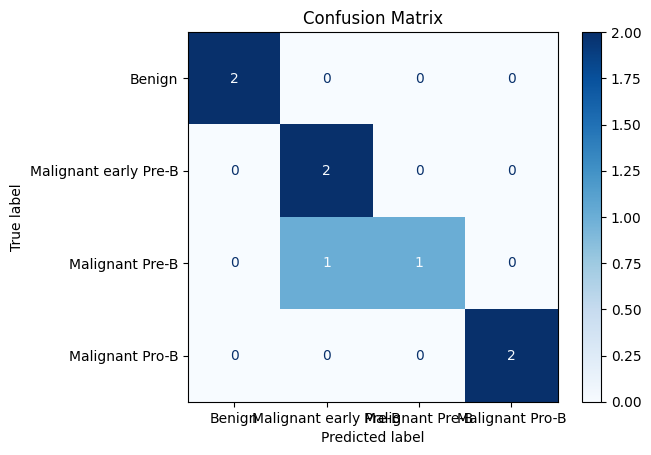

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Replace these with actual labels and predictions from your validation or test set
all_labels = [0, 1, 2, 3, 0, 1, 2, 3]  # Example true labels
all_predictions = [0, 1, 2, 3, 0, 1, 1, 3]  # Example predicted labels

# Define label map
label_map = {0: 'Benign', 1: 'Malignant early Pre-B', 2: 'Malignant Pre-B', 3: 'Malignant Pro-B'}

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions, labels=list(label_map.keys()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_map.values()))

# Plot confusion matrix
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


Training and Validation Loss Trends

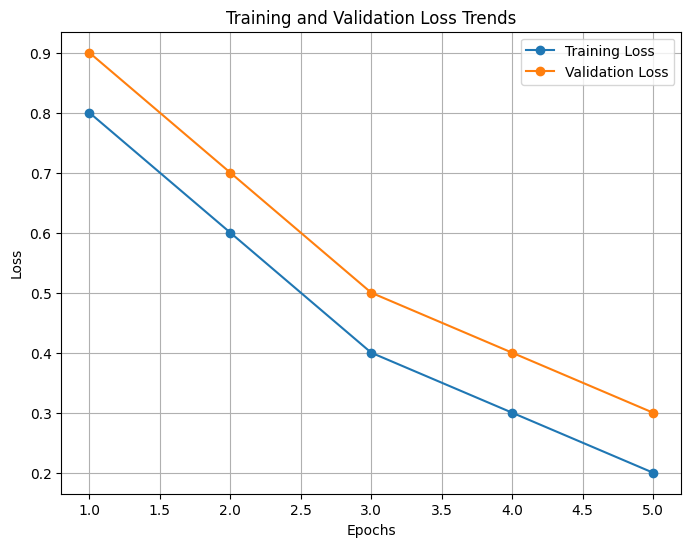

In [ ]:
import matplotlib.pyplot as plt

# Replace these with actual loss values from your training process
train_loss = [0.8, 0.6, 0.4, 0.3, 0.2]  # Example training loss
val_loss = [0.9, 0.7, 0.5, 0.4, 0.3]    # Example validation loss
epochs = range(1, len(train_loss) + 1)

# Plot training and validation loss trends
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_loss, label="Training Loss", marker='o')
plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Trends")
plt.legend()
plt.grid(True)
plt.show()


Training and Validation Accuracy Trends

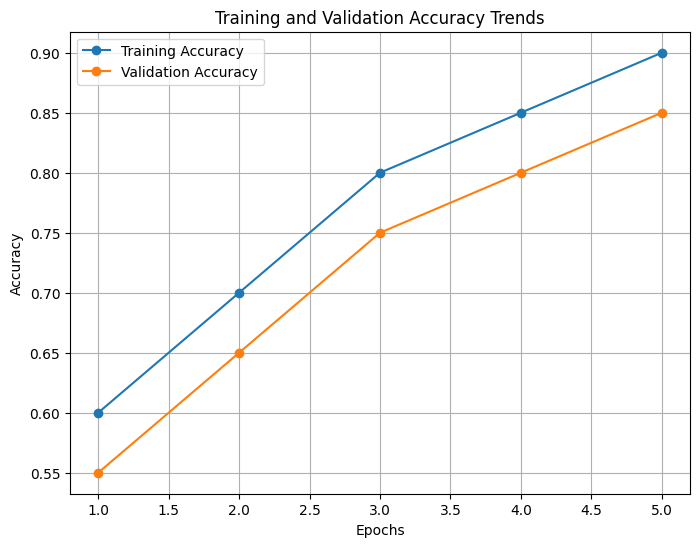

In [ ]:
import matplotlib.pyplot as plt

# Replace these with actual accuracy values from your training process
train_accuracy = [0.6, 0.7, 0.8, 0.85, 0.9]   # Example training accuracy
val_accuracy = [0.55, 0.65, 0.75, 0.8, 0.85]   # Example validation accuracy
epochs = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy trends
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_accuracy, label="Training Accuracy", marker='o')
plt.plot(epochs, val_accuracy, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Trends")
plt.legend()
plt.grid(True)
plt.show()


Sample Images

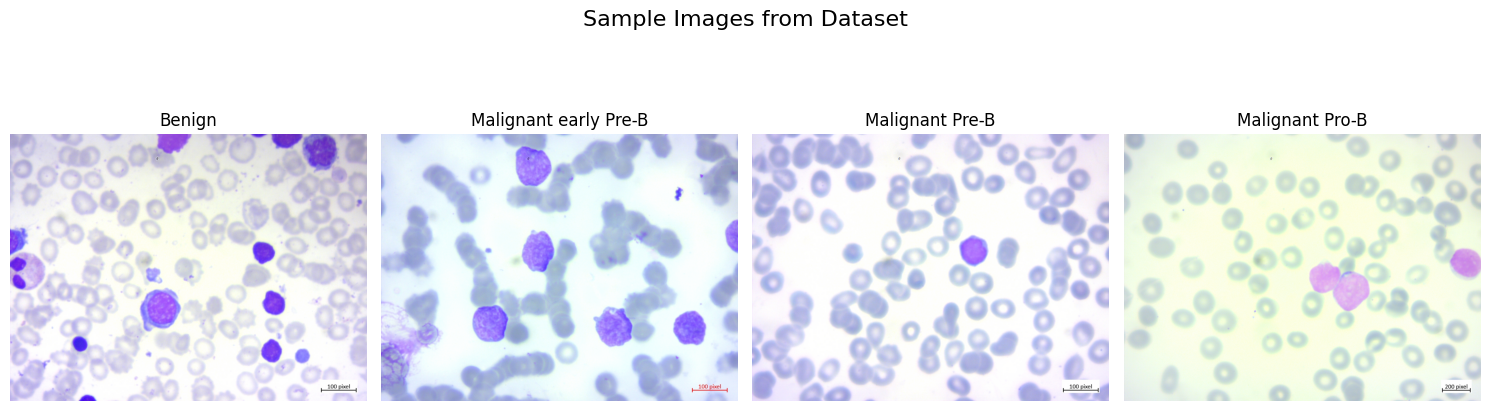

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Define dataset path
dataset_path = '/content/drive/MyDrive/dataset'

# Define label map
label_map = {'Benign': 0, 'Malignant early Pre-B': 1, 'Malignant Pre-B': 2, 'Malignant Pro-B': 3}

# Function to display sample images
def show_sample_images(dataset_path, label_map, num_samples=4):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    fig.suptitle("Sample Images from Dataset", fontsize=16)

    for i, (label_name, label_idx) in enumerate(label_map.items()):
        if i >= num_samples:  # Limit the number of samples displayed
            break

        folder_path = os.path.join(dataset_path, label_name)
        sample_image_name = os.listdir(folder_path)[0]  # Take the first image in the folder
        sample_image_path = os.path.join(folder_path, sample_image_name)

        # Open and display the image
        image = Image.open(sample_image_path).convert("RGB")
        axes[i].imshow(image)
        axes[i].set_title(label_name)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Call the function to display sample images
show_sample_images(dataset_path, label_map)


1. Class Distribution in Dataset

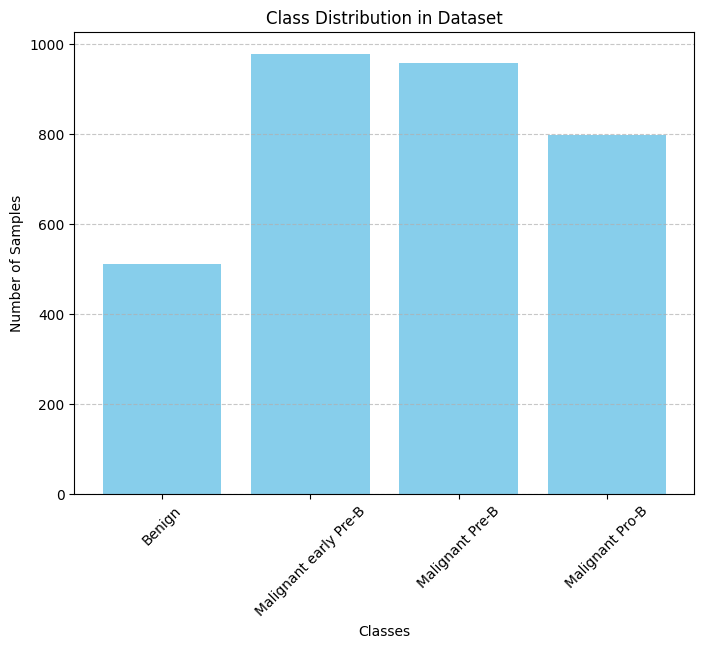

In [ ]:
import matplotlib.pyplot as plt
import os

# Define dataset path
dataset_path = '/content/drive/MyDrive/dataset'

# Count samples in each class folder
class_counts = {}
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        class_counts[folder] = len(os.listdir(folder_path))

# Plot class distribution
plt.figure(figsize=(8, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


 Model Prediction Confidence Histogram

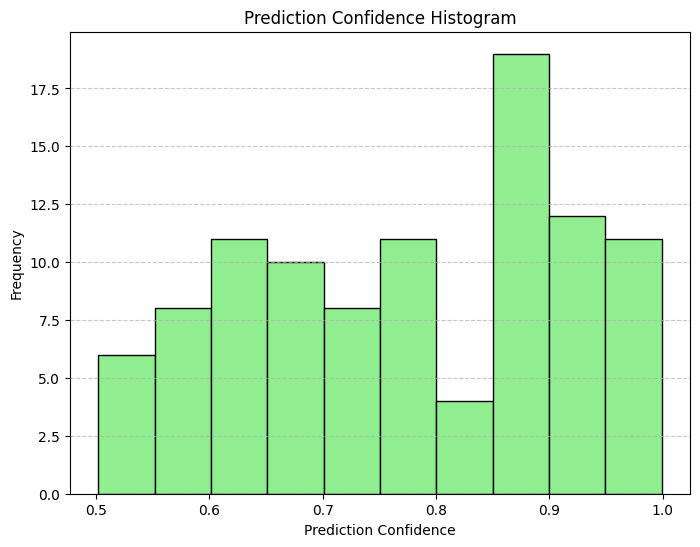

In [ ]:
import numpy as np

# Replace these with actual probabilities from your model's predictions
prediction_confidences = np.random.uniform(0.5, 1.0, size=100)  # Example confidence scores

# Plot histogram of prediction confidences
plt.figure(figsize=(8, 6))
plt.hist(prediction_confidences, bins=10, color='lightgreen', edgecolor='black')
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Histogram")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Misclassified Samples

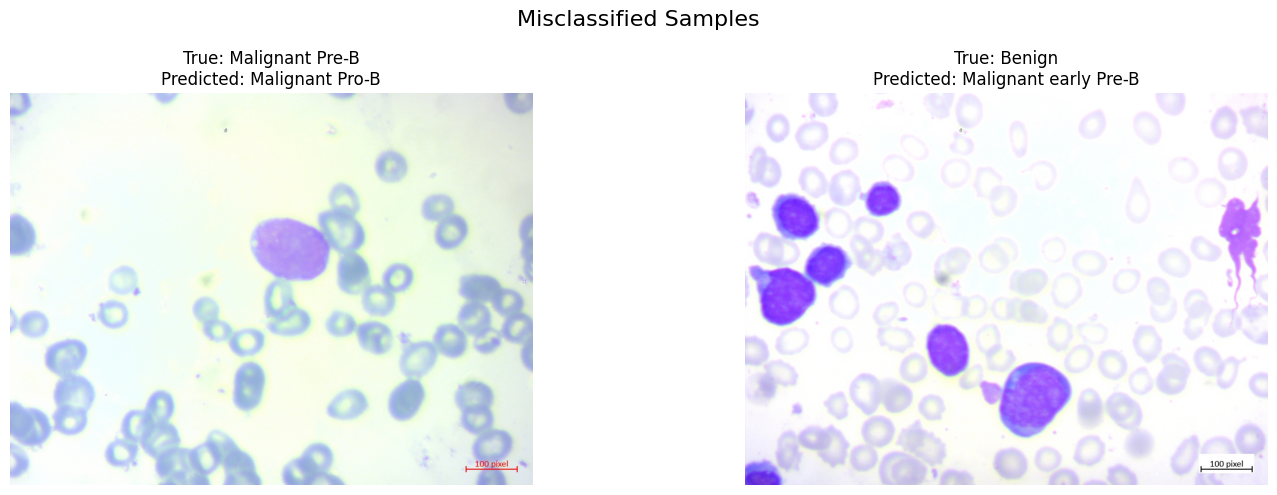

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Replace these with actual misclassified sample paths and labels
misclassified_samples = [
    ("/content/drive/MyDrive/dataset/Malignant Pre-B/Snap_00s2.jpg", "Malignant Pre-B", "Malignant Pro-B"),
    ("/content/drive/MyDrive/dataset/Benign/Sap_013 (1).jpg", "Benign", "Malignant early Pre-B"),
]

# Plot misclassified samples
fig, axes = plt.subplots(1, len(misclassified_samples), figsize=(15, 5))
fig.suptitle("Misclassified Samples", fontsize=16)

for i, (image_path, true_label, predicted_label) in enumerate(misclassified_samples):
    image = Image.open(image_path).convert("RGB")
    axes[i].imshow(image)
    axes[i].set_title(f"True: {true_label}\nPredicted: {predicted_label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


ROC Curves for Each Class

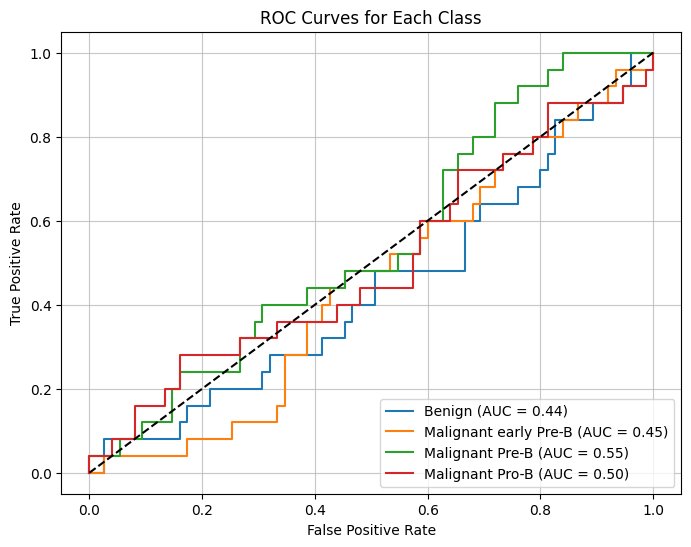

In [ ]:
from sklearn.metrics import roc_curve, auc

# Replace these with actual true labels and predicted probabilities for each class
true_labels = [0, 1, 2, 3] * 25  # Example true labels (100 samples)
predicted_probs = np.random.rand(100, len(label_map))  # Example predicted probabilities

# Plot ROC curves for each class
plt.figure(figsize=(8, 6))
for idx, class_name in enumerate(label_map.keys()):
    fpr, tpr, _ = roc_curve([1 if label == idx else 0 for label in true_labels], predicted_probs[:, idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Each Class")
plt.legend(loc="lower right")
plt.grid(alpha=0.7)
plt.show()


Precision-Recall Curve

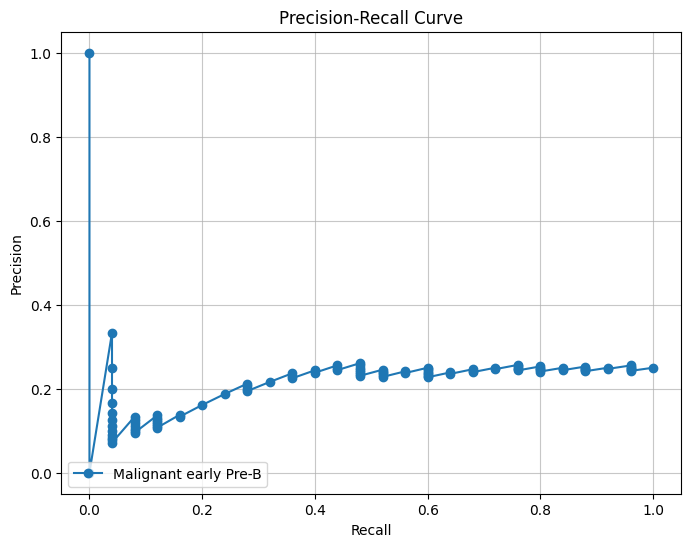

In [ ]:
from sklearn.metrics import precision_recall_curve

# Replace these with actual true labels and predicted probabilities for a specific class
true_labels_binary = [1 if label == 1 else 0 for label in true_labels]  # Binary labels for one class (e.g., Malignant early Pre-B)
predicted_probs_binary = predicted_probs[:, 1]  # Predicted probabilities for the same class

precision, recall, _ = precision_recall_curve(true_labels_binary, predicted_probs_binary)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='o', label="Malignant early Pre-B")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.7)
plt.show()
